## Bike Availability Forecasting using Time Series Analysis

To predict bike availability at stations using historical data and weather features

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

In [16]:
df_raw = pd.read_csv('final_merged_data.csv', low_memory=False)

print(f"Shape       : {df_raw.shape}")
print(f"Rows        : {len(df_raw):,}")
print(f"Stations    : {df_raw['station_id'].nunique()}")
print(f"Date range  : {df_raw['last_reported'].min()} → {df_raw['last_reported'].max()}")
df_raw.head(3)

Shape       : (298946, 78)
Rows        : 298,946
Stations    : 115
Date range  : 2024-12-01 00:10:00 → 2024-12-31 23:50:00


,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344006,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347107,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353333,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083


In [17]:
# Missing value audit
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
audit = pd.DataFrame({"missing": missing, "pct": missing_pct})
audit = audit[audit["missing"] > 0].sort_values("pct", ascending=False)
print(f"Columns with nulls: {len(audit)}")
print(audit.head(20))

Columns with nulls: 0
Empty DataFrame
Columns: [missing, pct]
Index: []


In [18]:
# Taret variable
print("num_bikes_available:")
print(df_raw["num_bikes_available"].describe().round(2))

num_bikes_available:
count    298946.00
mean         12.20
std           9.76
min           0.00
25%           4.00
50%          11.00
75%          19.00
max          40.00
Name: num_bikes_available, dtype: float64


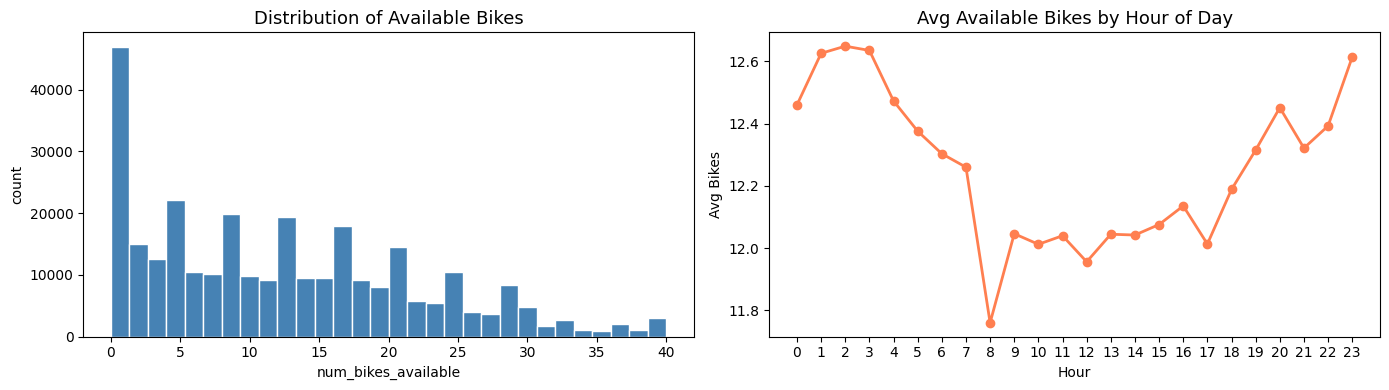

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw["num_bikes_available"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Available Bikes", fontsize=13)
axes[0].set_xlabel("num_bikes_available"); axes[0].set_ylabel("count")

hourly = df_raw.groupby("hour")["num_bikes_available"].mean()
axes[1].plot(hourly.index, hourly.values, marker="o", color="coral", linewidth=2)
axes[1].set_title("Avg Available Bikes by Hour of Day", fontsize=13)
axes[1].set_xlabel("Hour"); axes[1].set_ylabel("Avg Bikes")
axes[1].set_xticks(range(0, 24))

plt.tight_layout(); plt.show()

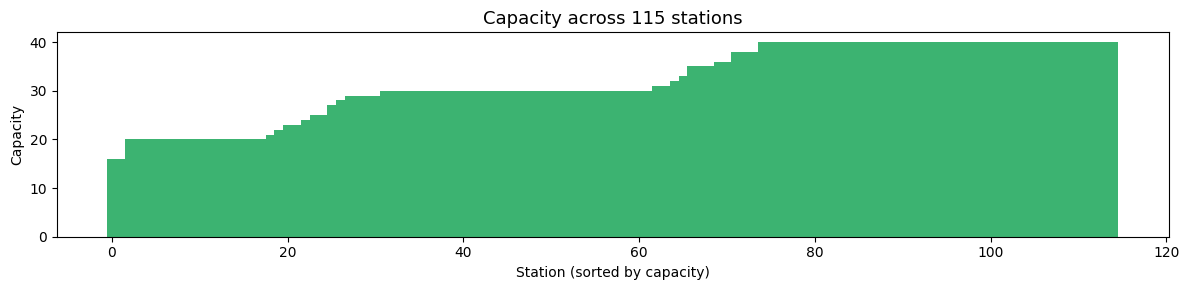

Capacity range: 16 - 40 docks


In [20]:
# Station capacity distribution
station_caps = df_raw.groupby("station_id")["capacity"].first().sort_values()
plt.figure(figsize=(12, 3))
plt.bar(range(len(station_caps)), station_caps.values, color="mediumseagreen", width=1)
plt.xlabel("Station (sorted by capacity)"); plt.ylabel("Capacity")
plt.title(f"Capacity across {len(station_caps)} stations", fontsize=13)
plt.tight_layout(); plt.show()
print(f"Capacity range: {station_caps.min()} - {station_caps.max()} docks")

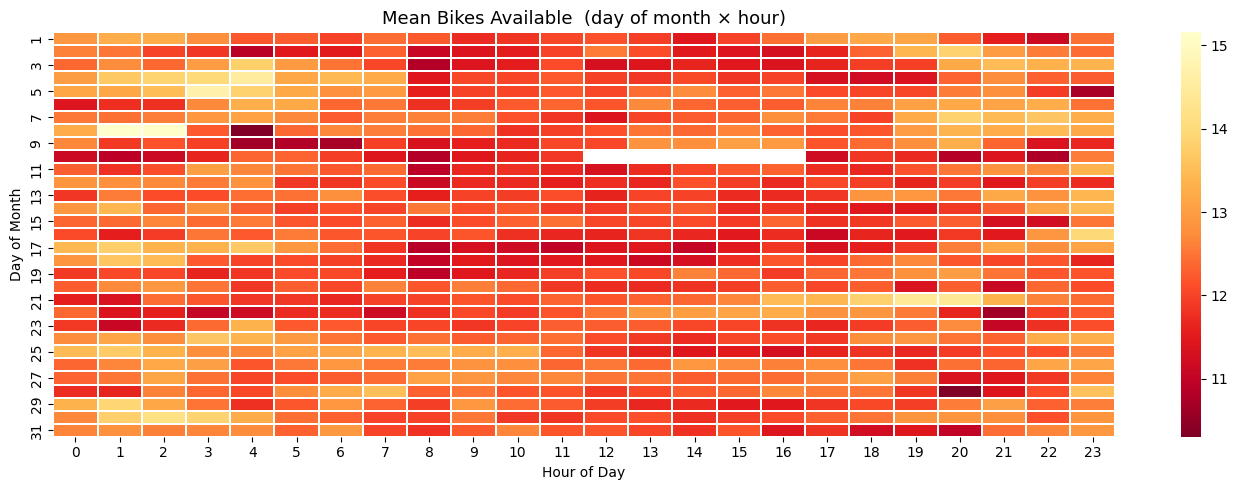

In [21]:
# Hourly x Day of Month bike availability heatmap
pivot = df_raw.pivot_table(values="num_bikes_available", index="day", columns="hour", aggfunc="mean")
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd_r", linewidths=0.3, fmt=".1f")
plt.title("Mean Bikes Available  (day of month × hour)", fontsize=13)
plt.xlabel("Hour of Day"); plt.ylabel("Day of Month")
plt.tight_layout(); plt.show()

## Feature Engineering

**Averaged weather features** – Met Éireann provides daily max/min; their average
approximates the period mean and avoids multicollinearity between two highly
correlated columns.

**`is_raining`** – binary flag derived when *both* max & min relative humidity
exceed 85 % (simple proxy for precipitation)

**Binary availability flag** – "will there be ≥ 3 bikes?" for reference.

## Bike and Dock Prediction Model

In [ ]:
df = df_raw.copy()

df["avg_temp"] = (df["max_air_temperature_celsius"]   + df["min_air_temperature_celsius"]) / 2
df["avg_humidity"] = (df["max_relative_humidity_percent"] + df["min_relative_humidity_percent"]) / 2
df["avg_pressure"] = (df["max_barometric_pressure_hpa"]   + df["min_barometric_pressure_hpa"])   / 2

# Rain proxy – both humidity extremes above 85 %
df["is_raining"] = (
    (df["max_relative_humidity_percent"] > 85) &
    (df["min_relative_humidity_percent"] > 85)
).astype(int)


CANDIDATE_FEATURES = [
    "station_id", "hour", "month", "capacity",
    "avg_temp", "avg_humidity", "avg_pressure", "is_raining",
]
REGRESSION_TARGET = "num_bikes_available"

df = df[CANDIDATE_FEATURES + [REGRESSION_TARGET, "bikes_available", "num_docks_available"]].dropna()

print(f"Rows after dropna : {len(df):,}")
print(f"Class balance (bikes_available=1): {df['bikes_available'].mean()*100:.1f}%")
print(f"Rain fraction: {df['is_raining'].mean()*100:.1f}%")
df[CANDIDATE_FEATURES].describe().round(2)

Rows after dropna : 298,946
Class balance (bikes_available=1): 79.3%
Rain fraction: 47.7%


,station_id,hour,month,capacity,avg_temp,avg_humidity,avg_pressure,is_raining
count,298946.00,298946.00,298946.0,298946.00,298946.00,298946.00,298946.00,298946.00
mean,57.97,11.52,12.0,31.98,7.79,84.28,1014.77,0.48
std,33.96,6.28,0.0,7.46,3.13,8.00,11.86,0.50
min,1.00,0.00,12.0,16.00,-3.48,55.07,975.04,0.00
25%,28.00,7.00,12.0,29.00,5.68,79.77,1005.92,0.00
50%,57.00,12.00,12.0,30.00,7.87,85.35,1017.12,0.00
75%,88.00,16.00,12.0,40.00,10.12,89.60,1022.62,1.00
max,117.00,23.00,12.0,40.00,14.63,98.85,1035.78,1.00


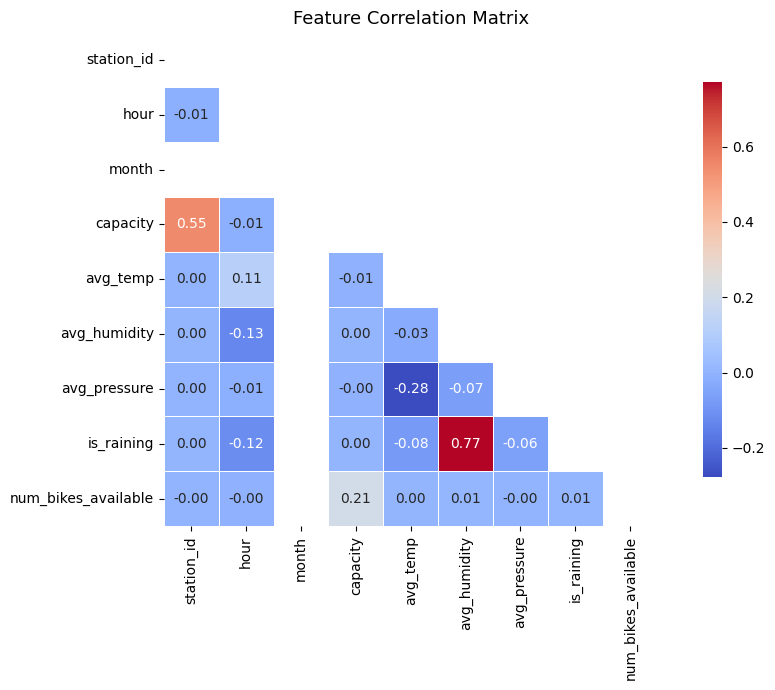

In [24]:
# Feature correlation matrix
plt.figure(figsize=(10, 7))
corr = df[CANDIDATE_FEATURES + [REGRESSION_TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout(); plt.show()

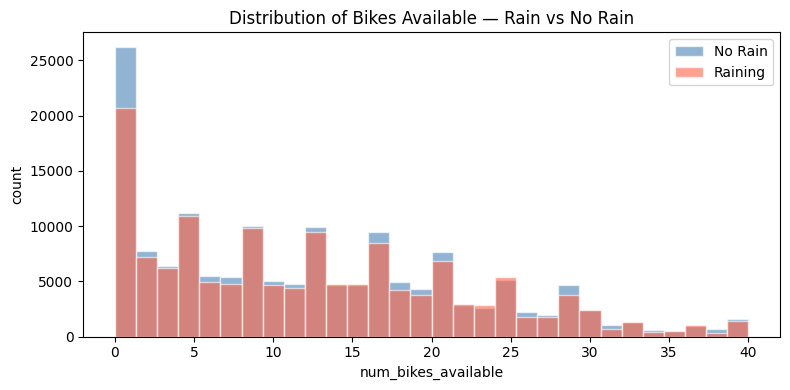

Mean bikes available:
  No Rain: 12.12
  Raining: 12.30


In [25]:
# Available Bikes: Rain vs No Rain
fig, ax = plt.subplots(figsize=(8, 4))
for flag, label, colour in [(0, "No Rain", "steelblue"), (1, "Raining", "tomato")]:
    vals = df[df["is_raining"] == flag][REGRESSION_TARGET]
    ax.hist(vals, bins=30, alpha=0.6, label=label, color=colour, edgecolor="white")
ax.set_xlabel("num_bikes_available"); ax.set_ylabel("count")
ax.set_title("Distribution of Bikes Available — Rain vs No Rain", fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()

print("Mean bikes available:")
for flag, label in [(0, "No Rain"), (1, "Raining")]:
    m = df[df["is_raining"] == flag][REGRESSION_TARGET].mean()
    print(f"  {label}: {m:.2f}")

## Feature Selection — SelectKBest (F-regression)

We pick the top-5 features by univariate F-score and **always force-include
`station_id`** — its integer values make the univariate score misleadingly low for
tree models, but trees can use it for per-station branching decisions.

In [26]:
K = 5
X_all = df[CANDIDATE_FEATURES]
y_all = df[REGRESSION_TARGET]

selector = SelectKBest(f_regression, k=K)
selector.fit(X_all, y_all)

scores_df = pd.DataFrame({
    "Feature" : CANDIDATE_FEATURES,
    "F-Score" : selector.scores_,
    "Selected": selector.get_support(),
}).sort_values("F-Score", ascending=False).reset_index(drop=True)

print(f"SelectKBest results (k={K}):")
print(scores_df.to_string(index=False))

kbest_features = scores_df[scores_df["Selected"]]["Feature"].tolist()
SELECTED_FEATURES = list(dict.fromkeys(["station_id"] + kbest_features))
print(f"\nFinal feature set: {SELECTED_FEATURES}")

SelectKBest results (k=5):
     Feature      F-Score  Selected
    capacity 13121.042326      True
  is_raining    23.847794      True
avg_humidity    22.409272      True
        hour     6.756964      True
avg_pressure     1.356716      True
    avg_temp     1.209129     False
  station_id     0.550011     False
       month     0.000000     False

Final feature set: ['station_id', 'capacity', 'is_raining', 'avg_humidity', 'hour', 'avg_pressure']


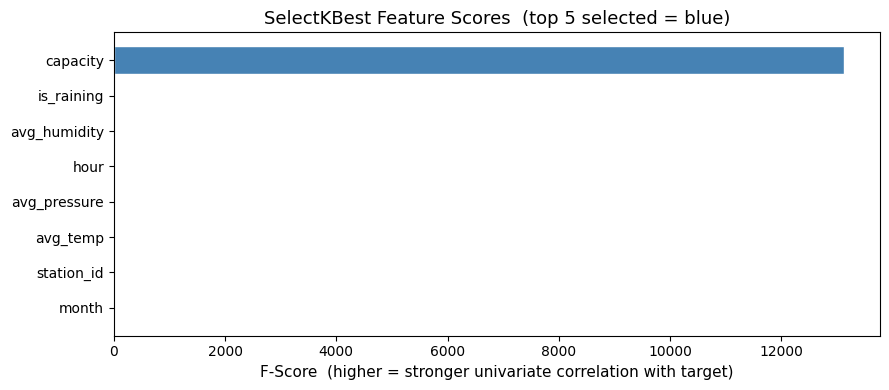

In [27]:
colours = ["steelblue" if s else "lightgrey" for s in scores_df["Selected"]]
plt.figure(figsize=(9, 4))
plt.barh(scores_df["Feature"], scores_df["F-Score"], color=colours, edgecolor="white")
plt.xlabel("F-Score  (higher = stronger univariate correlation with target)", fontsize=11)
plt.title(f"SelectKBest Feature Scores  (top {K} selected = blue)", fontsize=13)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

In [28]:
# Train / Test split (70/30)
X = df[SELECTED_FEATURES]
y = df[REGRESSION_TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {len(X_train):,} rows   Test: {len(X_test):,} rows")

Train: 209,262 rows   Test: 89,684 rows


In [29]:
regression_candidates = {
    "LinearRegression" : LinearRegression(),
    "Ridge"            : Ridge(alpha=1.0),
    "RandomForest"     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting" : GradientBoostingRegressor(
                             n_estimators=200, max_depth=5,
                             learning_rate=0.1, random_state=42),
}

reg_results = {}
print(f"{'Algorithm':<22}  {'MAE':>8}  {'R²':>8}")
print("-" * 44)

for name, model in regression_candidates.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    reg_results[name] = {"model": model, "mae": mae, "r2": r2, "pred": pred}
    print(f"{name:<22}  {mae:>8.4f}  {r2:>8.4f}")

best_name = min(reg_results, key=lambda k: reg_results[k]["mae"])
best      = reg_results[best_name]
print(f"\n Best model → {best_name}  (MAE={best['mae']:.4f}, R²={best['r2']:.4f})")

Algorithm                    MAE        R²
--------------------------------------------
LinearRegression          7.9134    0.0607
Ridge                     7.9134    0.0607
RandomForest              1.8224    0.8930
GradientBoosting          5.5327    0.4915

 Best model → RandomForest  (MAE=1.8224, R²=0.8930)


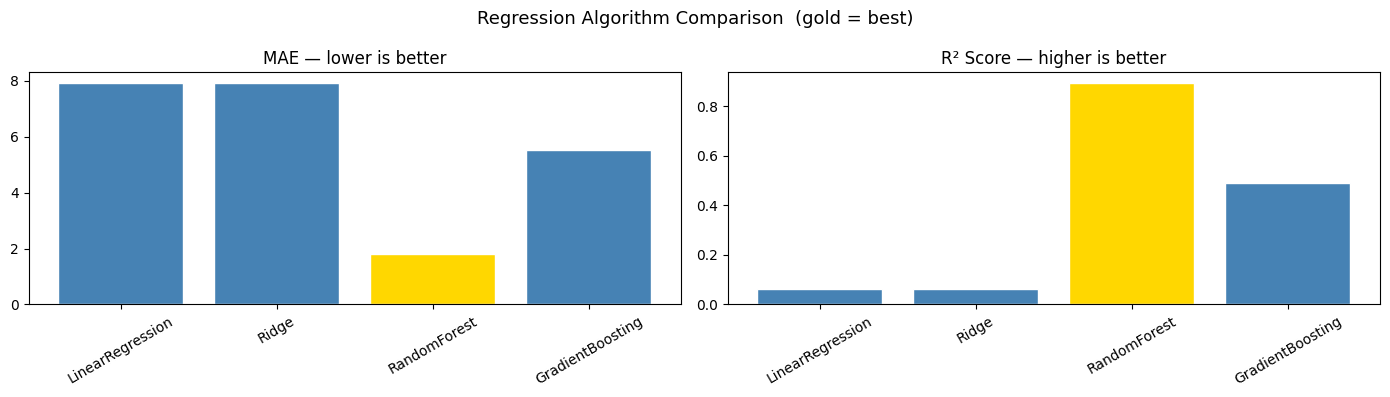

In [30]:
# Algorithms Comparison - MAE & R**2
names = list(reg_results.keys())
maes = [reg_results[n]["mae"] for n in names]
r2s = [reg_results[n]["r2"]  for n in names]
bar_colours = ["gold" if n == best_name else "steelblue" for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(names, maes, color=bar_colours, edgecolor="white")
axes[0].set_title("MAE — lower is better", fontsize=12)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(names, r2s, color=bar_colours, edgecolor="white")
axes[1].set_title("R² Score — higher is better", fontsize=12)
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("Regression Algorithm Comparison  (gold = best)", fontsize=13)
plt.tight_layout(); plt.show()

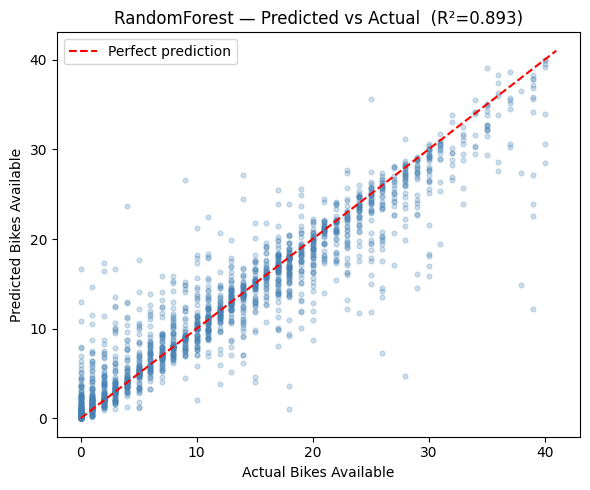

In [31]:
# Predicted vs Actual plot for best model
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
y_samp = np.array(y_test)[sample_idx]
p_samp = best["pred"][sample_idx]

plt.figure(figsize=(6, 5))
plt.scatter(y_samp, p_samp, alpha=0.25, s=12, color="steelblue")
lim = max(y_samp.max(), p_samp.max()) + 1
plt.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Bikes Available"); plt.ylabel("Predicted Bikes Available")
plt.title(f"{best_name} — Predicted vs Actual  (R²={best['r2']:.3f})", fontsize=12)
plt.legend(); plt.tight_layout(); plt.show()

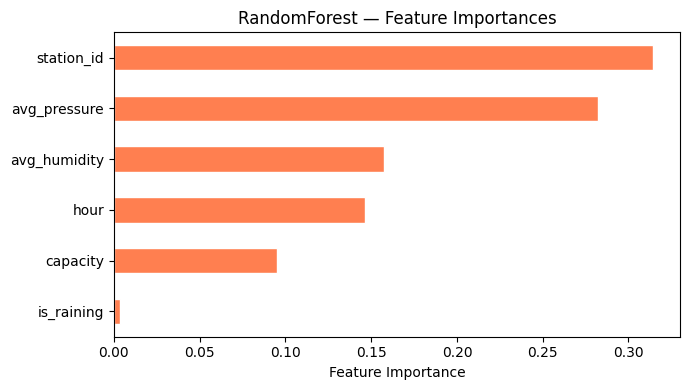

In [32]:
# Feature importance for RandomForest
rf_model = reg_results["RandomForest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=SELECTED_FEATURES).sort_values()

plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="coral", edgecolor="white")
plt.xlabel("Feature Importance")
plt.title("RandomForest — Feature Importances", fontsize=12)
plt.tight_layout(); plt.show()

In [33]:
# Docks sub-model
y_docks = df["num_docks_available"].values
X_d_train, X_d_test, yd_train, yd_test = train_test_split(
    X, y_docks, test_size=0.3, random_state=42
)
dock_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dock_model.fit(X_d_train, yd_train)
dock_pred  = dock_model.predict(X_d_test)
print(f"Docks model  MAE : {mean_absolute_error(yd_test, dock_pred):.4f}")
print(f"Docks model  R²  : {r2_score(yd_test, dock_pred):.4f}")

Docks model  MAE : 1.8250
Docks model  R²  : 0.9163


In [34]:
# Weather Sub-model 
WX_FEATURES = ["hour", "month"]
wx_targets = {
    "weather_temp"     : "avg_temp",
    "weather_humidity" : "avg_humidity",
    "weather_pressure" : "avg_pressure",
    "weather_rain"     : "is_raining",
}

wx_models = {}
X_wx = df[WX_FEATURES]

for model_key, col in wx_targets.items():
    y_wx = df[col]
    Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(X_wx, y_wx, test_size=0.3, random_state=42)
    m = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    m.fit(Xw_tr, yw_tr)
    yw_pred = m.predict(Xw_te)
    wx_models[model_key] = m
    print(f"{model_key:<22}  MAE={mean_absolute_error(yw_te, yw_pred):.4f}"
          f"  R²={r2_score(yw_te, yw_pred):.4f}")

weather_temp            MAE=2.5056  R²=0.0610
weather_humidity        MAE=5.9771  R²=0.0962
weather_pressure        MAE=9.7179  R²=0.0017
weather_rain            MAE=0.4651  R²=0.0663


In [35]:
# save models
import pathlib
OUTPUT_DIR = pathlib.Path("../bike_forecast")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_DIR / "bike_model.pkl",  "wb") as f: pickle.dump(best["model"], f)
print("Saved: bike_model.pkl")

with open(OUTPUT_DIR / "docks_model.pkl", "wb") as f: pickle.dump(dock_model, f)
print("Saved: docks_model.pkl")

for key, m in wx_models.items():
    with open(OUTPUT_DIR / f"{key}.pkl", "wb") as f: pickle.dump(m, f)
    print(f"Saved: {key}.pkl")

meta = {
    "best_model"        : best_name,
    "bike_features"     : SELECTED_FEATURES,
    "weather_features"  : WX_FEATURES,
    "mae"               : round(best["mae"], 4),
    "r2"                : round(best["r2"],  4),
    "target"            : REGRESSION_TARGET,
    "humidity_std_mean" : round(float(df["avg_humidity"].std()), 4),
}
with open(OUTPUT_DIR / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved: model_meta.json")
print()
print(json.dumps(meta, indent=2))

Saved: bike_model.pkl
Saved: docks_model.pkl
Saved: weather_temp.pkl
Saved: weather_humidity.pkl
Saved: weather_pressure.pkl
Saved: weather_rain.pkl
Saved: model_meta.json

{
  "best_model": "RandomForest",
  "bike_features": [
    "station_id",
    "capacity",
    "is_raining",
    "avg_humidity",
    "hour",
    "avg_pressure"
  ],
  "weather_features": [
    "hour",
    "month"
  ],
  "mae": 1.8224,
  "r2": 0.893,
  "target": "num_bikes_available",
  "humidity_std_mean": 8.0048
}
